# Brownian motion

Een van de bekendste voorbeelden van botsende deeltjes in de natuur is Brownian motion.
Fijn gemalen pollen in water lijken te dansen in willekeurige richting.
Dit komt doordat de pollen worden geraakt door watermoleculen die in alle richtingen bewegen.
Omdat de pollen veel zwaarder zijn dan watermoleculen, dus de beweging van de pollen is veel langzamer en minder "intens" dan die van de watermoleculen.
Dit proces van willekeurige beweging door botsingen met kleinere deeltjes wordt Brownian motion genoemd en kunnen we simuleren op basis van ons (premature) botsingsmodel.
Daarbij kunnen we ook gebruik maken van de zojuist geleerde manier van tracking van deeltjes, waarbij we een zowel het zware bolletjes als een enkel deeltje kunnen volgen.

Let op!
We bestuderen hier nog geen thermische effecten, deze opdrachten zijn met name bedoeld om beter te begrijpen hoe het botsingsmodel in elkaar zit.

```{warning}
In dit notebook zitten delen waar ruimte is om code toe te voegen, maar waarbij je denkt... waarom dan?
In een latere opdracht moet je terug naar die cell en de juiste code toevoegen.
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Aanmaken van de randvoorwaarden en initiele condities
Box_size_0 = 10
Box_length_0 = Box_size_0/2
Box_length = Box_length_0     # De grootte van de box kan wijzigen!

# Particles
dt = 0.1
particles = []
N = 40
v_0 = 1



In [3]:
# Maken van de ParticleClass

class ParticleClass:
    # Het maken van het deeltje
    def __init__(self, m, v, r, R, c):
        self.m = m                         
        self.v = np.array(v, dtype=float)  
        self.r = np.array(r, dtype=float)  
        self.R = np.array(R, dtype=float)  
        self.c = c

    # Het updaten van de positie, eventueel met zwaartekracht
    def update_position(self):
        self.r += self.v * dt #+ 1/2 * a * dt**2  
              
    # Harde wand
    def boxcollision(self):
        if abs(self.r[0]) + self.R > Box_length: 
            self.v[0] = -self.v[0]                                  # Omdraaien van de snelheid
            self.r[0] = np.sign(self.r[0]) * (Box_length - self.R)  # Zet terug net binnen box                 
        if abs(self.r[1]) + self.R > Box_length: 
            self.v[1] = -self.v[1]     
            self.r[1] = np.sign(self.r[1]) * (Box_length - self.R) 
            
    @property
    def momentum(self):
        return self.m * self.v
    
    @property
    def kin_energy(self):
        return 1/2 * self.m * np.dot(self.v, self.v)

In [4]:

# Aanmaken van deeltjes
for i in range(N-1):
    vx = np.random.uniform(-v_0,v_0)
    vy = np.random.choice([-1, 1])*np.sqrt(v_0**2-vx**2)        
    pos = Box_length_0*np.random.uniform(-1,1,2)
    particles.append(ParticleClass(m=1.0, v=[vx, vy], r = pos, R=.5,c='blue')) 

particles.append(ParticleClass(m=20.0, v=[0, 0], r = [0, 0], R=.5,c='red')) 


```{exercise} Brownian motion
:label: ex-brownian-1

Leg uit wat er in de laatste regel van bovenstaande script gebeurt.
Voeg voor deze regel goede metadata toe.
in the last line the code calls for a particle of mass 20, velocity of 0 in the x and y, sitting at the origin with a radius of 1/2 and is red, this is in contast with the 39 other praticles nof mass 1 which are randomly assigned a velocity, position and are instead asigned the color blue

```{solution} ex-brownian-1
#your code/answer
#creates 40 particles of size .5 with various masses, one of these stands still at the origin and the others are assigned random velocities

Er is een doos vol met deeltjes op willekeurige positie aangemaakt.
We willen kijken waar de deeltjes zijn terechtgekomen.
Hieronder staat dit weergegeven. 



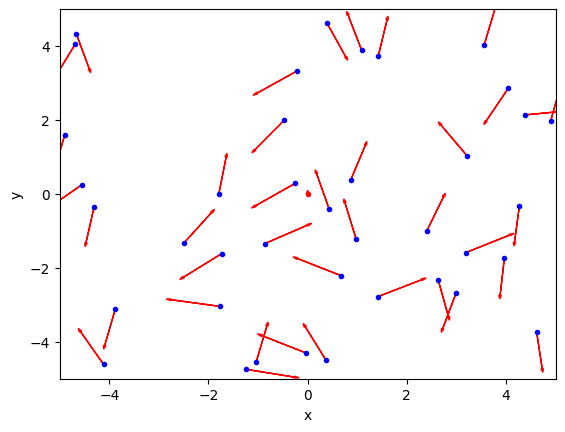

In [5]:
# Inspecteren van beginsituatie
#creates a plot along x and y axis the size of the box we called for in the sim parameters

plt.figure()

plt.xlabel('x')
plt.ylabel('y')

plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)

#plops each particle we perviously created and plops them onto the plot, they are then each assigned an arrow that is placed on their exact position and radiates in the exact direction of their initial velocities, these arrows are however not proportional to the particle's true magnitiudes and are the same width and length

for particle, particle_object in enumerate(particles):
    plt.plot(particle_object.r[0],particle_object.r[1],color=particle_object.c,marker='.')
    plt.arrow(particle_object.r[0],particle_object.r[1], 
               particle_object.v[0],particle_object.v[1], 
               head_width=0.05, head_length=0.1, color='red')
plt.show()


```{exercise} 
:label: ex-brownian-2

Er staat ook code met comments ervoor, wat doet deze code? 
Check je antwoord door de comments weg te halen.
Hoe wordt er voor gezorgd dat de snelheid van elk deeltje gelijk is?
```

```{solution} ex-brownian-2
#creates a plot along x and y axis the size of the box we called for in the sim parameters


#plops each particle we perviously created and plops them onto the plot, they are then each assigned an arrow that is placed on their exact position and radiates in the exact direction of their initial velocities, these arrows are however not proportional to the particle's true magnitiudes and are the same width and length

```

We gaan nu de functies van de simulatie weer aanroepen:

In [6]:
# Het bepalen of er een botsing plaats vindt
def collide_detection(self, other):
    dx = self.r[0] - other.r[0]
    dy = self.r[1] - other.r[1]
    rr = self.R + other.R
    return  dx**2+dy**2 < rr**2 
        
def particle_collision(p1: ParticleClass, p2: ParticleClass):
    """ past snelheden aan uitgaande van overlap """
    m1, m2 = p1.m, p2.m
    delta_r = p1.r - p2.r
    delta_v = p1.v - p2.v
    dot_product = np.dot(delta_r, delta_v)
    
    # Als deeltjes van elkaar weg bewegen dan geen botsing
    if dot_product >= 0: # '='-teken voorkomt ook problemen als delta_r == \vec{0}
        return
    
    distance_squared = np.dot(delta_r, delta_r) 
    # Botsing oplossen volgens elastische botsing in 2D
    p1.v -= 2 * m2 / (m1 + m2) * dot_product / distance_squared * delta_r
    p2.v += 2 * m1 / (m1 + m2) * dot_product / distance_squared * delta_r



def handle_collisions(particles):
    global counter
    """ alle onderlinge botsingen afhandelen voor deeltjes in lijst """
    num_particles = len(particles)
    for i in range(num_particles):
        for j in range(i+1, num_particles):
            if collide_detection(particles[i], particles[j]):
                delta_r = particles[i].r - particles[j].r
                delta_v = particles[i].v - particles[j].v
                if np.dot(delta_r, delta_v) < 0:
                    particle_collision(particles[i], particles[j])
                    counter += 1
#your code/answer


In onderstaande code geven we de code voor de simulatie en volgen we de positie van het zware deeltje. 

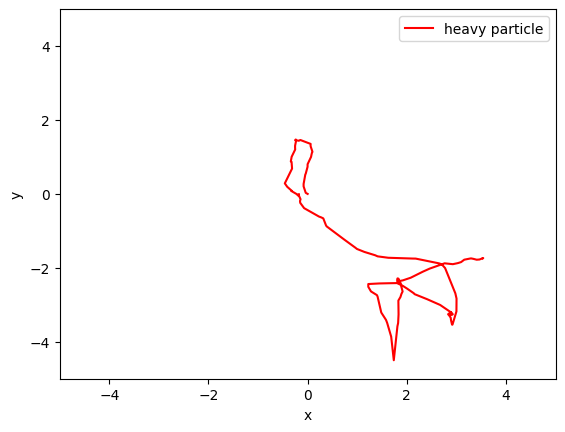

In [ ]:
# tracken van het zware deeltje
track_x = []
track_x_sm = []
track_y = []
track_y_sm = []

counter_data = []

for i in range(1000):
    
    counter=0
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje
        
    handle_collisions(particles)

    counter_data.append(counter)
    
    track_x.append(particles[N-1].r[0])
    track_y.append(particles[N-1].r[1])
    track_x_sm.append(particles[N-2].r[0])
    track_y_sm.append(particles[N-2].r[1])
    

plt.figure()
plt.plot(track_x,track_y,'r', label='heavy particle')
#plt.plot(track_x_sm,track_y_sm,'b', label='light particle')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)
plt.legend()
plt.show()

```{exercise} Brownian motion in beeld
:label: ex-brownian-3
- Draai de onderstaande simulatie een keer en bestudeer de output.
- Voeg zelf een tweede tracking toe van een licht deeltje en verbeter de plot.
- Wat zijn overeenkomsten en verschillen tussen de beweging van de twee deeltjes?
- Wat valt je op als je de simulatie een aantal keer runt?
```

```{solution} ex-brownian-3
#your code/answer
some of the biggest differences ar ethe behaviors of the motions, in the same 'time snap-shots' that the both particles experience, the smaller particle travels further and thus it's path charted has straighterlines signifying that it is going way faster than the snapshot itself can track, this is in comparision to the heavy particle which is slower in velocity and thus the path that it takes is much more curved as the snapshots are timed so that it takes tinier incriments of the path and like a accurate integral is able to create a neater curve. tldr: the light praticle is faster than the heavier one (shocker). what i also notice is that the sim seems to suffer from the shortcomings of pervious sims where the heavy particle cannot be consistently set up at the origin due to the nature of the code. also some more would be ways to lable the start and end of the paths or at least some way to tell the head from the tail of the particle. more obvious things that appear along side running the sim more than once is that the parcticles go in different directions at different velocities each time, reflecting the simulated randomess of the bouces

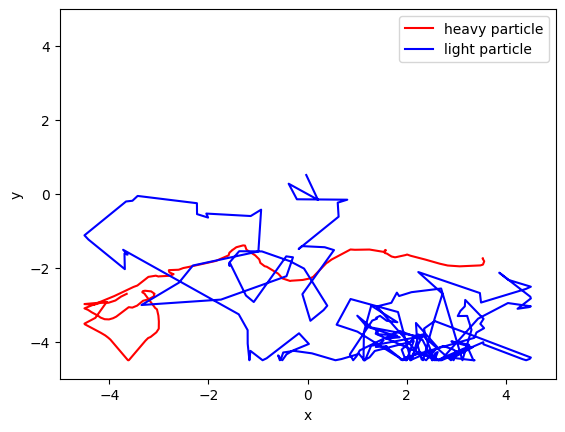

In [8]:

# tracken van het zware deeltje
track_x = []
track_x_sm = []
track_y = []
track_y_sm = []

for i in range(1000):
    
    for p in particles:
        p.update_position()    # Update positie        
        p.boxcollision()         # Wandbotsing werkt per deeltje
        
    handle_collisions(particles)

    
    track_x.append(particles[N-1].r[0])
    track_y.append(particles[N-1].r[1])
    track_x_sm.append(particles[N-2].r[0])
    track_y_sm.append(particles[N-2].r[1])
    

plt.figure()
plt.plot(track_x,track_y,'r', label='heavy particle')
plt.plot(track_x_sm,track_y_sm,'b', label='light particle')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-Box_length_0,Box_length_0)
plt.ylim(-Box_length_0,Box_length_0)
plt.legend()
plt.show()

We zouden gevoel willen krijgen voor het aantal botsingen dat per tijdseenheid plaatsvindt. 
Elke keer dat er een botsing plaatsvindt, zou de counter met 1 omhoog moeten gaan.
Idealiter wordt het aantal botsingen opgeslagen in een array zodat je het aantal botsingen als functie van de tijd kunt weergeven.

```{exercise}
Pas bovenstaand idee toe in de eerder gemaakte code.
Plot hieronder het aantal botsingen als functie van de tijd.
```

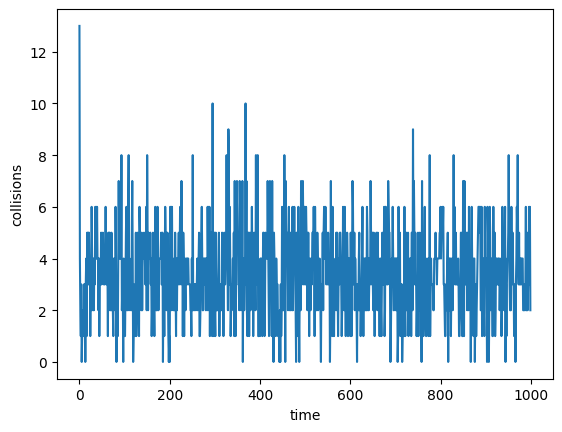

In [9]:
plt.figure()
plt.plot(counter_data)
plt.xlabel('time')
plt.ylabel('collisions')
plt.show()

```{warning} 🌶 Let op!
:icon: false
De onderstaande opdrachten vallen buiten de stof maar tellen mee als je excellent wilt behalen.
```

In zulke fysica modellen is de afgelegde weg (afstand tussen begin en eindpunt) van belang.
Deze afgelegde weg zegt iets over de snelheid van difussie.
Idealiter bekijken we een histogram.
Maar voor een histogram hebben we veel deeltjes nodig.



```{exercise} Afgelegde weg 🌶
:label: ex-brownian-4

- Maak een simulatie met 361 deeltjes, waarvan 1 zwaar deeltje.
- Houd rekening met de boxgrootte, deze moet mee schalen!
- Maak een histogram van de afgelegde weg voor alle deeltjes. 
- Geef de afgelegde weg van het grote deeltje duidelijk aan.
```


In [10]:
#your code/answer


En nu we toch bezig zijn met twee verschillende deeltjes.... 

We kunnen twee "groepen" van deeltjes aanmaken, elk  met een andere massa. Als we dan de zwaartekracht aan zetten, dan zouden we verwachten dat de lichtere deeltjes boven komen "drijven".

```{exercise} Onderzoek dit vermoeden 🌶
- maak daartoe de box 2x zo hoog als breed
- verdubbel het totaal aantal deeltjes
- zet een artificieel grote zwaartekracht aan
```

In [11]:
#your code/answer
